In [1]:
import tarfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from fairchem.core.datasets import AseDBDataset

os.chdir('../..')

from utils.load_datasets import OMol25

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0203 14:28:16.856000 43271 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [ ]:
loader = OMol25()
df, counts = loader.get_omol25(sample_size=1000)

2026-02-03 14:28:16.942 | INFO     | utils.load_datasets:_prepare_data:31 - Found existing extracted data at data/OMol25/output/neutral_val
2026-02-03 14:28:16.963 | INFO     | utils.load_datasets:_prepare_data:36 - Fairchem dataset loaded with 27697 entries.
2026-02-03 14:28:16.964 | INFO     | utils.load_datasets:get_omol25:50 - Beginning data processing for 1000 entries.
Extracting OMol25 Properties: 100%|██████████| 1000/1000 [00:00<00:00, 3884.02it/s]
2026-02-03 14:28:17.243 | INFO     | utils.load_datasets:get_omol25:88 - Data extraction finished. Creating DataFrame.
2026-02-03 14:28:17.245 | INFO     | utils.load_datasets:get_omol25:92 - DataFrame created with 1000 rows.
2026-02-03 14:28:17.245 | INFO     | utils.load_datasets:get_omol25:93 - Detected elements: ['N', 'Si', 'C', 'O', 'H', 'S', 'F', 'Cl', 'B', 'I', 'Br', 'P', 'K', 'Ca', 'Li', 'Na', 'Mg']


   index  num_atoms        formula  potential_energy  num_electrons  \
0      0         12      CH5NO3Si2     -24497.652661             70   
1      1         62     C24H33N3OS     -42772.472573            222   
2      2         58  C19H25F3N6O4S     -56228.345938            256   
3      3         57  C22H23Cl2N7O3     -64804.772662            262   
4      4         17       C3H9NOS3     -39296.201060             90   

   n_scf_steps  n_basis        homo_lumo_gap  nl_energy  
0           16      325  [7.778456329223449]   7.659100  
1           15     1382  [8.022379193545877]  21.940902  
2           15     1476  [9.099541909320454]  26.403264  
3           15     1492  [8.253539917822877]  26.867800  
4           15      407  [8.698391656549234]   9.590965  
Counter({'H': 18451, 'C': 15575, 'O': 3910, 'N': 2897, 'F': 835, 'S': 761, 'Cl': 528, 'Br': 187, 'P': 145, 'I': 93, 'Si': 47, 'B': 20, 'K': 20, 'Na': 15, 'Li': 11, 'Ca': 10, 'Mg': 6})


### 1. Distribution of Number of Atoms per Molecule
This histogram visualizes the distribution of the number of atoms present in each molecule within the dataset. The x-axis represents the 'Number of Atoms', and the y-axis shows the 'Frequency', indicating how many molecules fall into each range of atom counts. This plot helps us understand the typical size of molecules in the dataset and identify if there are any prevalent size categories or unusual molecular sizes.

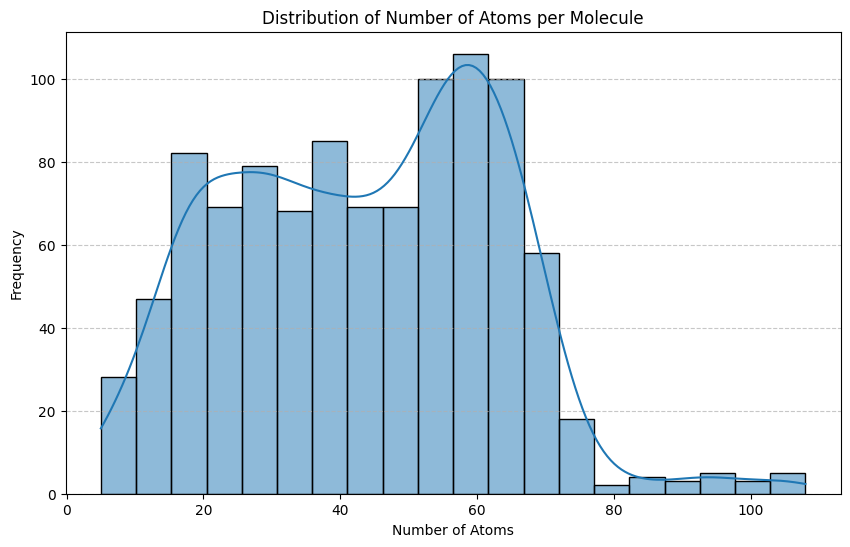

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_atoms'], bins=20, kde=True)
plt.title('Distribution of Number of Atoms per Molecule')
plt.xlabel('Number of Atoms')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Distribution of Chemical Elements
This bar chart displays the frequency of different chemical elements found across all molecules in the dataset. The x-axis lists the 'Chemical Elements', and the y-axis represents their 'Count', indicating how many times each element appears. By observing this plot, we can quickly identify the most common and rare elements in our molecular structures, providing insight into the dataset's chemical composition.

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_43271/3755227813.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(elements), y=list(counts), palette='viridis')


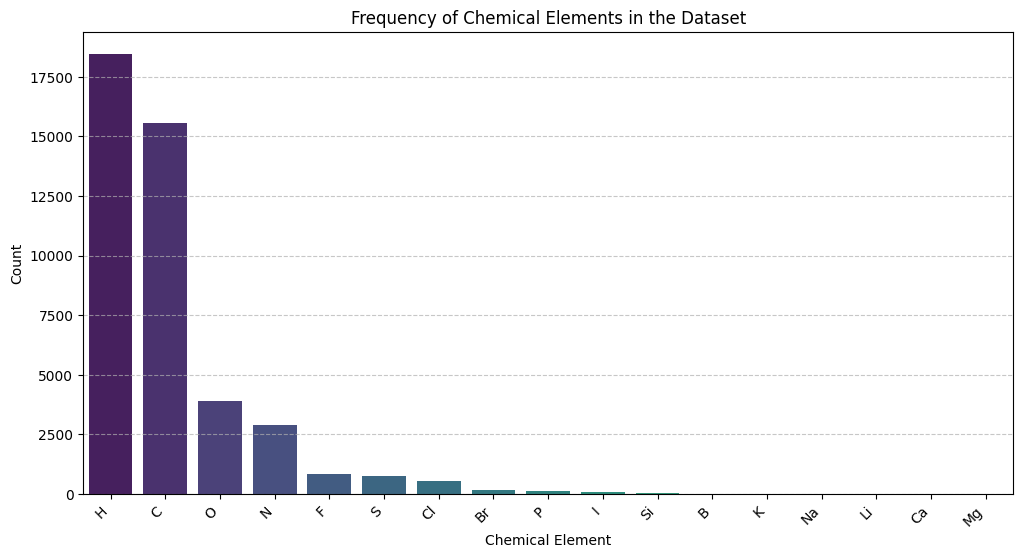

In [4]:
elements, counts = zip(*counts.most_common())

plt.figure(figsize=(12, 6))
sns.barplot(x=list(elements), y=list(counts), palette='viridis')
plt.title('Frequency of Chemical Elements in the Dataset')
plt.xlabel('Chemical Element')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Distribution of Potential Energies
This histogram shows the distribution of potential energies for the molecules in the dataset. The x-axis denotes 'Potential Energy (eV)', and the y-axis shows the 'Frequency' of molecules within each energy range. This visualization is crucial for understanding the energy landscape of the dataset, revealing whether the molecules tend to have similar energies or exhibit a wide spectrum of energy values. It can also highlight any clusters of molecules at specific energy levels.

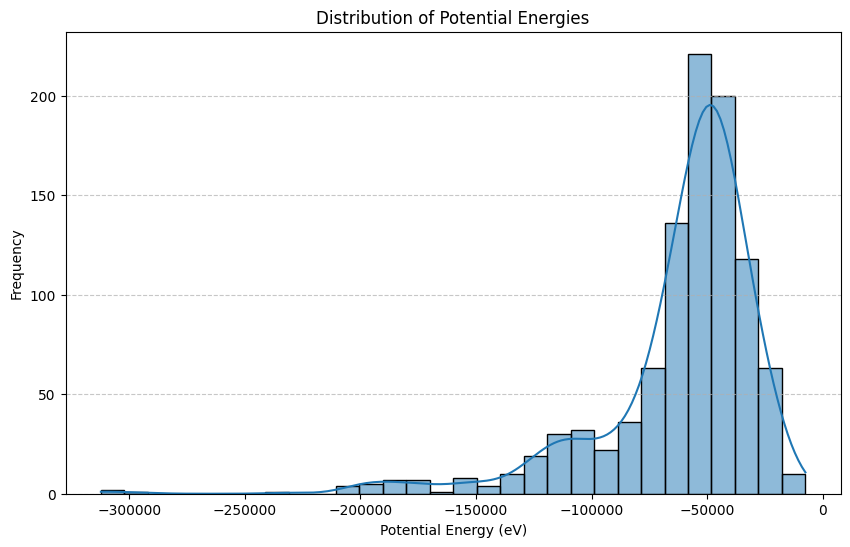

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['potential_energy'], bins=30, kde=True)
plt.title('Distribution of Potential Energies')
plt.xlabel('Potential Energy (eV)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Distribution of Number of Electrons

This histogram shows the distribution of the total number of electrons in each molecule. The x-axis represents the 'Number of Electrons', and the y-axis shows the 'Frequency'. This plot helps in understanding the range and common values for the electronic count of the molecules in the dataset, which can correlate with molecular size and complexity.

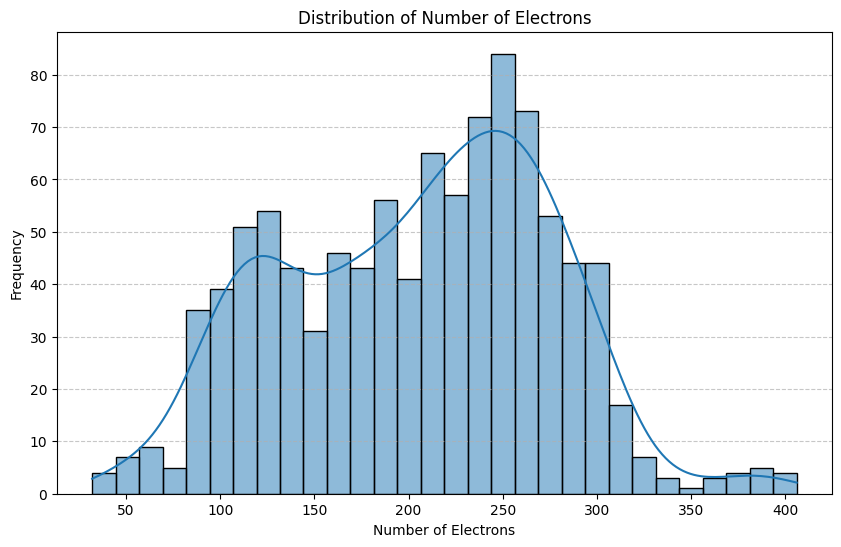

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_electrons'], bins=30, kde=True)
plt.title('Distribution of Number of Electrons')
plt.xlabel('Number of Electrons')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 5. Distribution of SCF Steps

This plot visualizes the number of self-consistent field (SCF) steps required for the electronic structure calculations. The x-axis indicates the 'Number of SCF Steps', and the y-axis shows the 'Frequency'. This distribution can highlight the computational effort typically involved in converging calculations for molecules in this dataset.

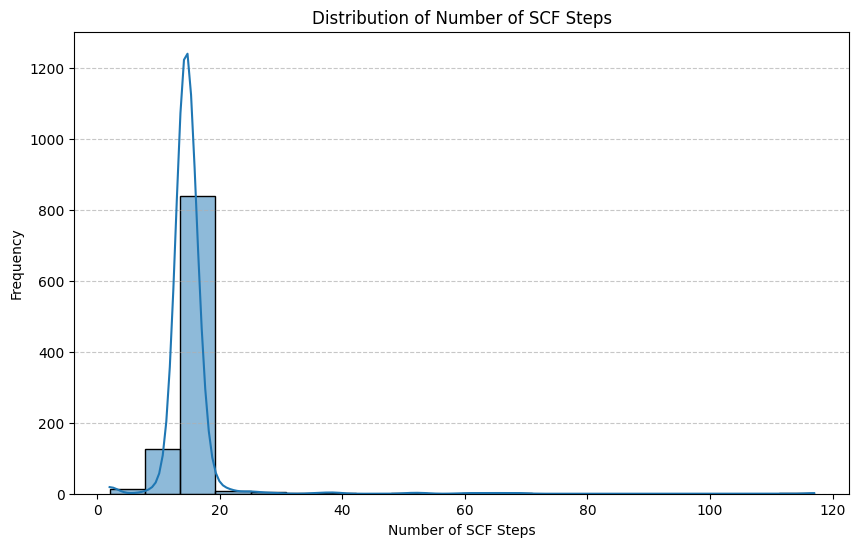

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['n_scf_steps'], bins=20, kde=True)
plt.title('Distribution of Number of SCF Steps')
plt.xlabel('Number of SCF Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Distribution of Number of Basis Functions

This histogram illustrates the distribution of the number of basis functions used in the electronic structure calculations for each molecule. The x-axis denotes the 'Number of Basis Functions', and the y-axis represents the 'Frequency'. This plot provides insight into the size and flexibility of the atomic orbital sets employed, which directly impacts the accuracy and computational cost of the calculations.

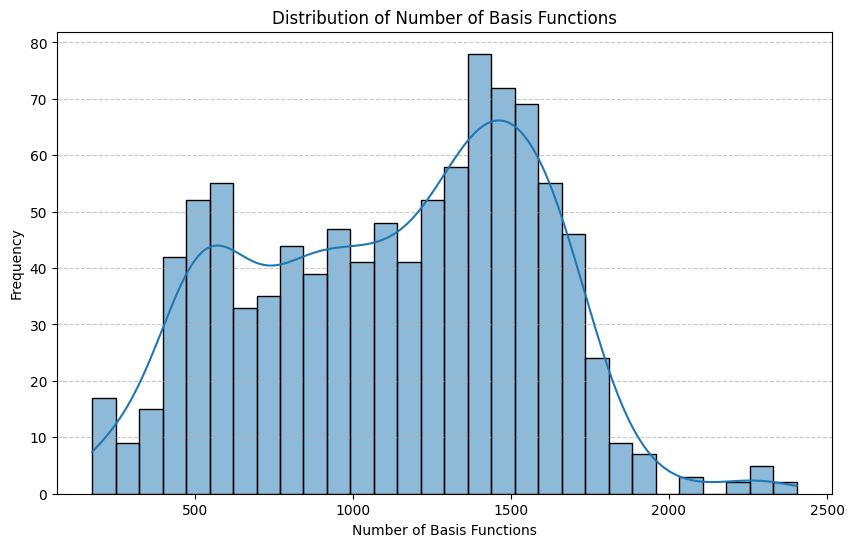

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['n_basis'], bins=30, kde=True)
plt.title('Distribution of Number of Basis Functions')
plt.xlabel('Number of Basis Functions')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 7. Distribution of Non-Local Energy

This histogram illustrates the distribution of the non-local energy component for the molecules in the dataset. The x-axis represents 'Non-Local Energy', and the y-axis shows the 'Frequency'. Non-local correlation energies are crucial in accurate DFT calculations, and their distribution can shed light on the nature of interatomic interactions within the molecules and the applicability of specific density functionals.

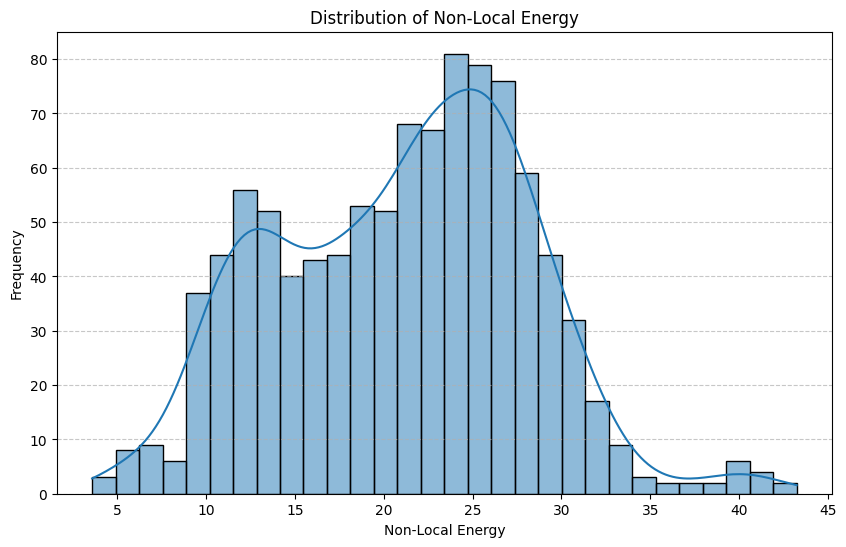

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['nl_energy'], bins=30, kde=True)
plt.title('Distribution of Non-Local Energy')
plt.xlabel('Non-Local Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()